In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [9]:
VA_data_path = 'D:/Projects/URIS/URIS/WEMOM_V1/Data/Text_Dataset/text_data.csv'
save_path = 'D:/Projects/URIS/URIS/WEMOM_V1/Data/Text_Dataset/text_VA.csv'
df = pd.read_csv(VA_data_path)

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\27980\AppData\Local\Temp\ipykernel_59604\3874145882.py:7: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Valence\Arousal')


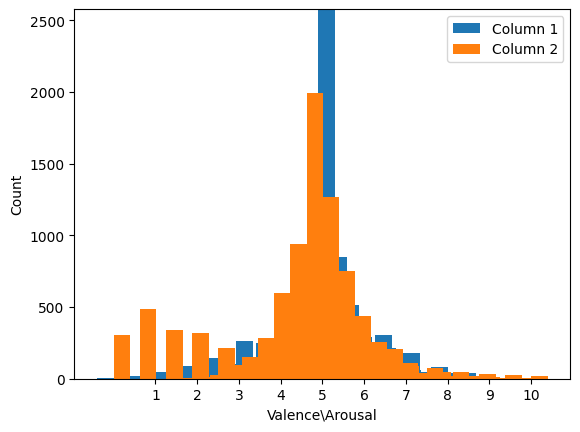

In [10]:
count_valence = df['Valence'].value_counts().sort_index()
count_arousal = df['Arousal'].value_counts().sort_index()

plt.bar(count_valence.index - 0.2, count_valence.values, width=0.4, label='Column 1', align='center')
plt.bar(count_arousal.index + 0.2, count_arousal.values, width=0.4, label='Column 2', align='center')

plt.xlabel('Valence\Arousal')
plt.ylabel('Count')
plt.xticks(range(1, 11))  
plt.ylim(0, max(count_valence.max(), count_arousal.max()) + 1) 
plt.legend()
plt.show()

In [11]:
data1 = df['Valence'].tolist()
data2 = df['Arousal'].tolist()

print("Data1 (Valence):", data1)
print("Data2 (Arousal):", data2)

kde1 = stats.gaussian_kde(data1)
kde2 = stats.gaussian_kde(data2)

Data1 (Valence): [5.29, 4.71, 6.59, 6.91, 7.06, 5.29, 5.59, 6.03, 6.03, 6.03, 5.29, 6.09, 6.97, 4.94, 4.41, 6.76, 7.15, 7.35, 6.76, 5.71, 5.59, 5.29, 6.76, 7.88, 6.03, 7.35, 6.47, 6.38, 7.06, 5.29, 6.15, 6.56, 7.06, 6.47, 5.29, 5.65, 4.41, 7.65, 5.29, 5.29, 5.59, 5.29, 5.65, 5.29, 4.76, 6.65, 6.09, 5.56, 5.62, 4.88, 4.18, 5.62, 6.76, 6.03, 5.29, 5.29, 6.47, 5.29, 5.29, 5.59, 5.65, 6.94, 6.47, 5.29, 5.59, 5.29, 6.15, 5.59, 5.88, 6.97, 6.47, 6.47, 5.0, 5.0, 5.71, 6.76, 5.0, 5.29, 5.71, 5.29, 5.29, 7.35, 6.41, 5.29, 6.47, 5.59, 7.06, 5.29, 5.88, 5.29, 5.0, 7.06, 7.06, 4.32, 7.59, 5.59, 5.65, 4.88, 5.29, 6.41, 6.41, 6.47, 6.18, 7.35, 5.29, 5.29, 5.88, 5.29, 4.71, 7.06, 2.76, 6.03, 5.29, 5.29, 7.18, 7.06, 6.18, 5.29, 5.29, 3.47, 3.0, 6.59, 4.41, 5.59, 7.06, 7.06, 8.24, 5.59, 4.12, 5.29, 5.59, 6.03, 7.65, 4.41, 5.59, 5.0, 4.71, 7.85, 4.88, 5.88, 5.29, 3.24, 5.0, 4.03, 2.94, 6.47, 6.76, 5.29, 5.29, 4.41, 6.76, 6.56, 6.15, 6.94, 5.94, 5.29, 2.35, 5.29, 5.29, 5.88, 5.29, 6.18, 3.82, 4.97, 5.29,

   Original Value  Transformed Value
0            5.29           5.083544
1            4.71           4.357808
2            6.59           6.846348
3            6.91           7.292805
4            7.06           7.493596


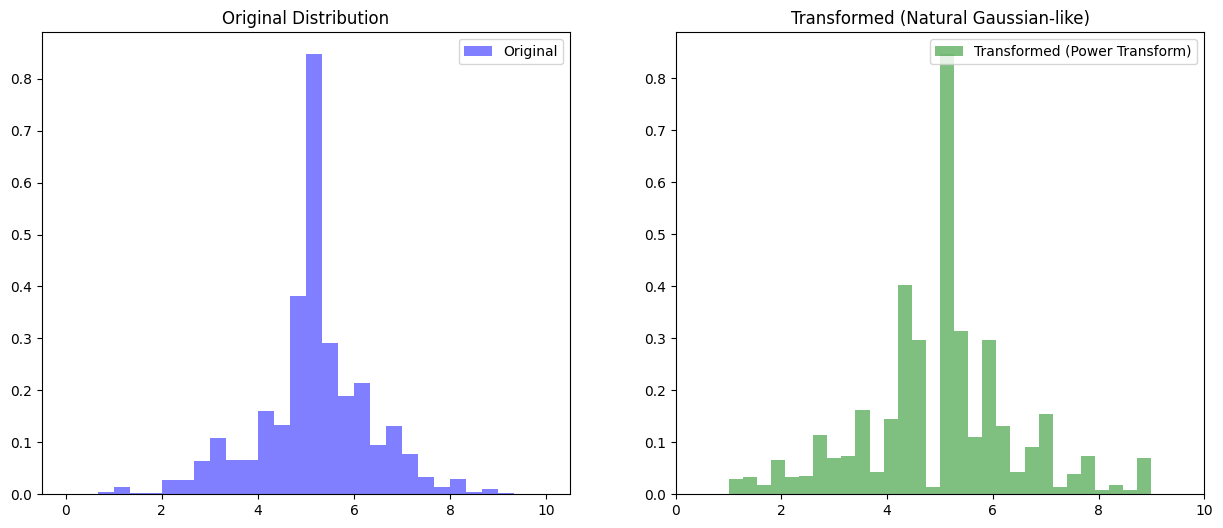

Correlation between old and new Valence: 0.9957


In [16]:
# 1. Add VERY SMALL variation (Jitter)
np.random.seed(42)
noise_level = 0.01 
data1_jittered = np.array(data1) + np.random.uniform(-noise_level, noise_level, size=len(data1))

# STRATEGY: Power Transform (Yeo-Johnson)
# Unlike QuantileTransformer which forces a specific shape (Normal/Uniform), 
# PowerTransformer tries to make data "more Gaussian-like" but respects the original data structure better.
# It usually fixes skewness and spreads data out, but won't force a perfect bell curve or flat block.
from sklearn.preprocessing import PowerTransformer

data1_np = data1_jittered.reshape(-1, 1)
pt1 = PowerTransformer(method='yeo-johnson', standardize=True)
new_data1_transformed = pt1.fit_transform(data1_np).flatten()

# Standardize logic: Mean=0, Std=1 -> Map to Mean=5, Std=1.5 (Range roughly [1, 9])
# This preserves the "Natural" look but reduces the extreme peak at 5.
new_data1 = new_data1_transformed * 1.5 + 5.0
new_data1 = np.clip(new_data1, 1.0, 9.0)

result_df1 = pd.DataFrame({
    'Original Value': data1,
    'Transformed Value': new_data1,
}, index=df.index)  

print(result_df1.head())

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.hist(data1, bins=30, density=True, alpha=0.5, color='blue', label='Original')
plt.title('Original Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(new_data1, bins=30, density=True, alpha=0.5, color='green', label='Transformed (Power Transform)')
plt.title('Transformed (Natural Gaussian-like)')
plt.xlim(0, 10)
plt.legend()
plt.show()

print(f"Correlation between old and new Valence: {np.corrcoef(data1, new_data1)[0,1]:.4f}")

   Original Value  Transformed Value
0            4.62           5.133056
1            5.00           5.519969
2            4.62           5.140024
3            5.65           6.177977
4            5.77           6.294475


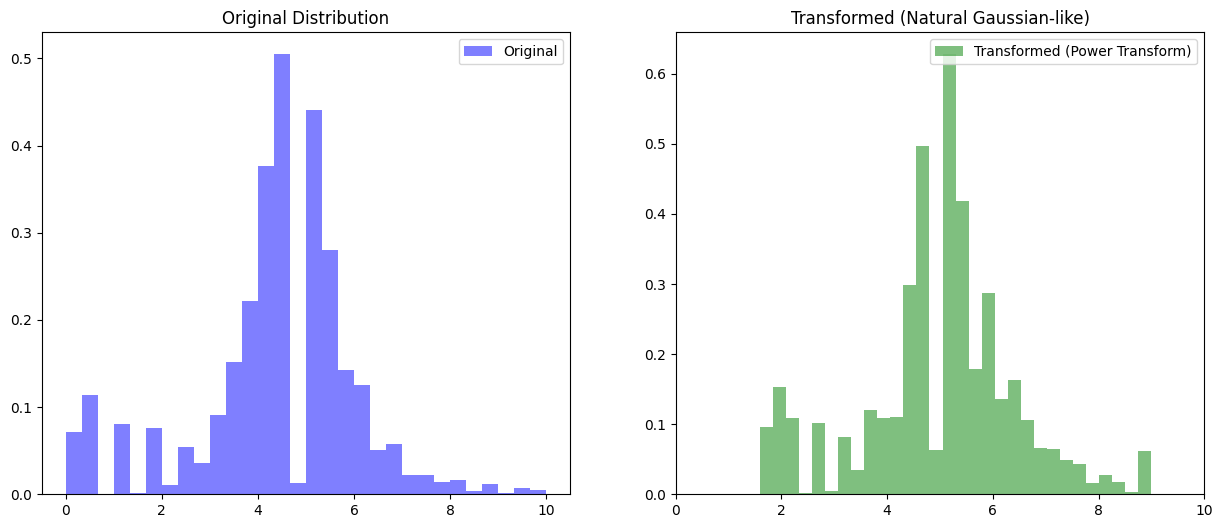

Correlation between old and new Arousal: 0.9941


In [17]:
# Do the same for Arousal (data2)
np.random.seed(42)
data2_jittered = np.array(data2) + np.random.uniform(-noise_level, noise_level, size=len(data2))
data2_np = data2_jittered.reshape(-1, 1)

pt2 = PowerTransformer(method='yeo-johnson', standardize=True)
new_data2_transformed = pt2.fit_transform(data2_np).flatten()

# Scale
new_data2 = new_data2_transformed * 1.5 + 5.0
new_data2 = np.clip(new_data2, 1.0, 9.0)

result_df2 = pd.DataFrame({
    'Original Value': data2,
    'Transformed Value': new_data2,
}, index=df.index)  

print(result_df2.head())

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.hist(data2, bins=30, density=True, alpha=0.5, color='blue', label='Original')
plt.title('Original Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(new_data2, bins=30, density=True, alpha=0.5, color='green', label='Transformed (Power Transform)')
plt.title('Transformed (Natural Gaussian-like)')
plt.xlim(0, 10)
plt.legend()
plt.show()

print(f"Correlation between old and new Arousal: {np.corrcoef(data2, new_data2)[0,1]:.4f}")

In [18]:
valence_lst = new_data1.round(2)
arousal_lst = new_data2.round(2)

In [19]:
print(f"Number of Arousal: {len(arousal_lst)}")
print(f"Number of Valence: {len(valence_lst)}")

Number of Arousal: 12840
Number of Valence: 12840


In [20]:
# Update the DataFrame with the transformed values
df['Valence'] = valence_lst
df['Arousal'] = arousal_lst

# Save the transformed dataframe
print(f"Saving transformed data to {save_path}...")
df.to_csv(save_path, index=False)
print("Done!")

Saving transformed data to D:/Projects/URIS/URIS/WEMOM_V1/Data/Text_Dataset/text_VA.csv...
Done!
